In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from tqdm.notebook import tqdm

# allow imports from utils/
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Plotting functions

In [2]:
def volcano_plot(
    data,
    ref_group_name,
    log2fc_col="log2FoldChange",
    padj_col="padj",
    name_col="gene_name",
    significance_level=0.05,
    top_n_genes=5,
    pt_color="gray",
    up_color="green",
    down_color="red",
    figsize=[6, 4],
    size=5,
    fontsize=5,
):
    """
    Plot a volcano plot from a DataFrame with columns 'padj' and 'log2FC'.

    Parameters:
    - data: DataFrame containing 'padj', 'log2FC', and 'gene' columns.
    - significance_level: Significance level for coloring points (default is 0.05).
    - top_n_genes: Number of top genes to annotate (default is 5).
    """

    # Create a new column for color based on log2FC and significance level
    data["color"] = pt_color
    data.loc[
        (data[log2fc_col] > 0) & (data[padj_col] < significance_level), "color"
    ] = up_color
    data.loc[
        (data[log2fc_col] < 0) & (data[padj_col] < significance_level), "color"
    ] = down_color

    # Plotting
    fig, ax = plt.subplots(figsize=figsize)
    green_scatter = plt.scatter(
        data[data["color"] == up_color][log2fc_col],
        -1 * np.log10(data[data["color"] == up_color][padj_col]),
        c=up_color,
        alpha=0.7,
        label="Up in {}".format(ref_group_name),
        s=size,
    )

    red_scatter = plt.scatter(
        data[data["color"] == down_color][log2fc_col],
        -1 * np.log10(data[data["color"] == down_color][padj_col]),
        c=down_color,
        alpha=0.7,
        label="Down in {}".format(ref_group_name),
        s=size,
    )

    gray_scatter = plt.scatter(
        data[data["color"] == "gray"][log2fc_col],
        -1 * np.log10(data[data["color"] == "gray"][padj_col]),
        c="gray",
        alpha=0.7,
        label="Not significant",
        s=size,
    )

    # Annotate top genes
    top_genes = data.nsmallest(top_n_genes, padj_col)
    for i, gene in top_genes.iterrows():
        ax.annotate(
            gene[name_col],
            (gene[log2fc_col], -1 * np.log10(gene[padj_col])),
            xytext=(5, 5),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=fontsize,
            weight="bold",
        )

    # Set plot labels and title
    ax.set_title("Volcano Plot")
    ax.set_xlabel(r"$\log_2(FC)$")
    ax.set_ylabel(r"$-\log_{10}(FDR)$")
    ax.legend()
    return fig, ax

# Differential expression between young and old fibroblasts

In [3]:
de_results = pd.read_csv("../data/young_old/deg_young_old.csv", index_col=0)

In [4]:
de_results["hgnc_symbol_filled"] = np.array(de_results.loc[:, "hgnc_symbol"])
de_results.loc[de_results.hgnc_symbol.isna(), "hgnc_symbol_filled"] = np.array(
    de_results.loc[de_results.hgnc_symbol.isna(), "ensembl_gene_id"].str[-6:]
)
de_results = de_results.drop_duplicates(subset="ensembl_gene_id", keep="first")
# de_results = de_results.dropna()
de_results.loc[:, "neg_log10_fdr"] = -np.log10(de_results["padj"])


alpha = 0.05
de_results.loc[:, "significant"] = de_results["padj"] < alpha

In [5]:
cleaned_de_results = de_results.dropna(
    subset=de_results.columns.difference(["hgnc_symbol"])
)
len(cleaned_de_results)

18238

In [56]:
ncrnas_down_in_old = (
    cleaned_de_results.loc[
        (cleaned_de_results["DE"] == "DOWN")
        & (cleaned_de_results["gene_biotype"] == "lncRNA")
        & (cleaned_de_results.significant == True),
        "ensembl_gene_id",
    ]
    .unique()
    .astype("str")
)

## Fig S13a

/tmp/ipykernel_3509163/763483193.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["color"] = pt_color


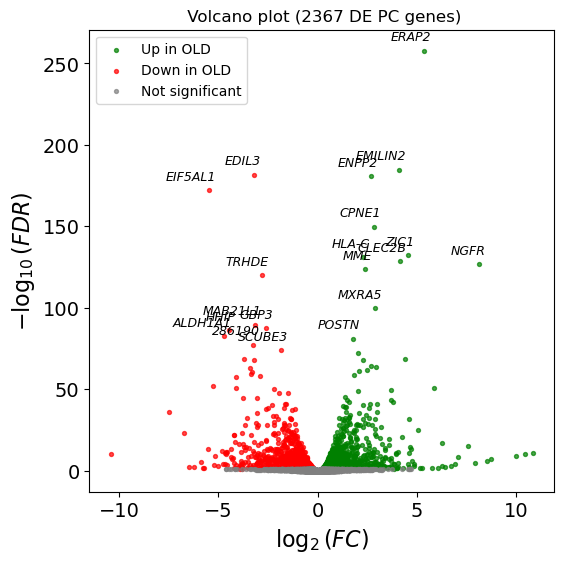

In [6]:
fig, ax = volcano_plot(
    cleaned_de_results.loc[cleaned_de_results.gene_biotype == "protein_coding"],
    ref_group_name="OLD",
    log2fc_col="log2FoldChange",
    padj_col="padj",
    name_col="hgnc_symbol_filled",
    significance_level=0.05,
    top_n_genes=20,
    figsize=[6, 6],
    size=8,
    fontsize=6,
)
ax.set_title(
    " Volcano plot ({} DE PC genes)".format(
        str(
            cleaned_de_results[
                (cleaned_de_results["gene_biotype"] == "protein_coding")
                & (cleaned_de_results["significant"])
            ].shape[0]
        )
    )
)
ax.set_xlabel(r"$\log_{2}(FC)$")

# Make gene labels italic and size 9
for text in ax.texts:
    text.set_fontsize(9)
    text.set_fontstyle("italic")  # <-- correct property
    text.set_fontweight("normal")  # ensure not bold


# Axis label font size
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

# Tick font size
ax.tick_params(axis="both", labelsize=14)

# Legend font size
legend = ax.get_legend()
if legend is not None:
    legend.set_title(legend.get_title().get_text(), prop={"size": 10})
    for text in legend.get_texts():
        text.set_fontsize(10)

plt.show()

## Fig 3a

In [7]:
cleaned_de_results["DE"] = "NA"
cleaned_de_results.loc[cleaned_de_results.log2FoldChange > 0, "DE"] = "UP"
cleaned_de_results.loc[cleaned_de_results.log2FoldChange < 0, "DE"] = "DOWN"
cleaned_de_results.loc[
    (cleaned_de_results.gene_biotype.isin(["lncRNA", "protein_coding"]))
    & (cleaned_de_results.significant == True)
].groupby(["gene_biotype", "DE"]).count().ensembl_gene_id

/tmp/ipykernel_3509163/3649333610.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_de_results["DE"] = "NA"


gene_biotype    DE  
lncRNA          DOWN      78
                UP       102
protein_coding  DOWN    1172
                UP      1195
Name: ensembl_gene_id, dtype: int64

/tmp/ipykernel_3509163/763483193.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["color"] = pt_color


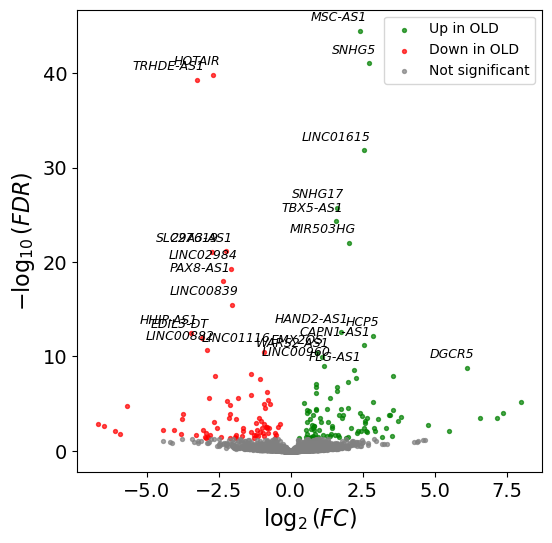

In [8]:
fig, ax = volcano_plot(
    cleaned_de_results.loc[cleaned_de_results.gene_biotype == "lncRNA"],
    ref_group_name="OLD",
    log2fc_col="log2FoldChange",
    padj_col="padj",
    name_col="hgnc_symbol_filled",
    significance_level=0.05,
    top_n_genes=25,
    figsize=[6, 6],
    size=8,
    fontsize=6,
)
ax.set_title(None)

# Make gene labels italic and size 9
for text in ax.texts:
    text.set_fontsize(9)
    text.set_fontstyle("italic")  # <-- correct property
    text.set_fontweight("normal")  # ensure not bold


# Axis label font size
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

# Tick font size
ax.tick_params(axis="both", labelsize=14)

# Legend font size
legend = ax.get_legend()
if legend is not None:
    legend.set_title(legend.get_title().get_text(), prop={"size": 10})
    for text in legend.get_texts():
        text.set_fontsize(10)

plt.show()

We save the `de_ncrnas`, used later on.

In [29]:
de_ncrnas = list(
    cleaned_de_results.loc[
        (cleaned_de_results.gene_biotype == "lncRNA")
        & (cleaned_de_results.significant),
        "ensembl_gene_id",
    ].unique()
)

# Geneset enrichment analysis

In [9]:
import gseapy as gp
from gseapy import barplot

def perform_go_analysis(
    foreground_genes,
    background_genes,
    gene_sets="GO_Biological_Process_2023",
    cutoff=0.05,
):
    """
    Perform Gene Ontology (GO) analysis using gseapy library.

    Parameters:
    - foreground_genes: List of Ensembl IDs for the foreground gene set.
    - background_genes: List of Ensembl IDs for the background gene set.

    Returns:
    - Enrichment results DataFrame.
    """

    # Run GO analysis using gseapy
    result = gp.enrichr(
        gene_list=foreground_genes,
        background=background_genes,
        gene_sets=gene_sets,
        outdir=None,  # You can specify an output directory if needed
        cutoff=cutoff,  # Adjust the cutoff as needed
    )  # Adjust the number of processes as needed

    # Return the enrichment results DataFrame
    return result.res2d

In [10]:
pc_universe = (
    de_results.loc[de_results.gene_biotype == "protein_coding", "hgnc_symbol"]
    .unique()
    .astype("str")
)
pc_universe = list(pc_universe[pc_universe != "nan"])

In [11]:
old_down_pc_genes = (
    cleaned_de_results.loc[
        (cleaned_de_results["DE"] == "DOWN")
        & (cleaned_de_results["gene_biotype"] == "protein_coding")
        & (cleaned_de_results.significant == True),
        "hgnc_symbol",
    ]
    .unique()
    .astype("str")
)
old_down_pc_genes = list(old_down_pc_genes[old_down_pc_genes != "nan"])

old_up_pc_genes = (
    cleaned_de_results.loc[
        (cleaned_de_results["DE"] == "UP")
        & (cleaned_de_results["gene_biotype"] == "protein_coding")
        & (cleaned_de_results.significant == True),
        "hgnc_symbol",
    ]
    .unique()
    .astype("str")
)
old_up_pc_genes = list(old_up_pc_genes[old_up_pc_genes != "nan"])

old_down_go_results = perform_go_analysis(
    old_down_pc_genes, pc_universe, gene_sets="GO_Biological_Process_2023"
)
old_down_go_results["Condition"] = "DOWN in OLD"

old_up_go_results = perform_go_analysis(
    old_up_pc_genes, pc_universe, gene_sets="GO_Biological_Process_2023"
)
old_up_go_results["Condition"] = "UP in OLD"
young_old_go_results = pd.concat([old_down_go_results, old_up_go_results])

max_length = 42
short_terms = []
for term in list(young_old_go_results.Term):
    if len(term) > max_length:
        term = term.split(" ")
        short_term = " ".join(term[:-1])
        short_term = short_term[:max_length] + "..."
        short_term = " ".join([short_term, term[-1]])
        short_terms.append(short_term)
    else:
        short_terms.append(term)
young_old_go_results["short_term"] = np.array(short_terms)
young_old_go_results["Term"] = short_terms

## Fig S13b

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/gseapy/plot.py:689: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(


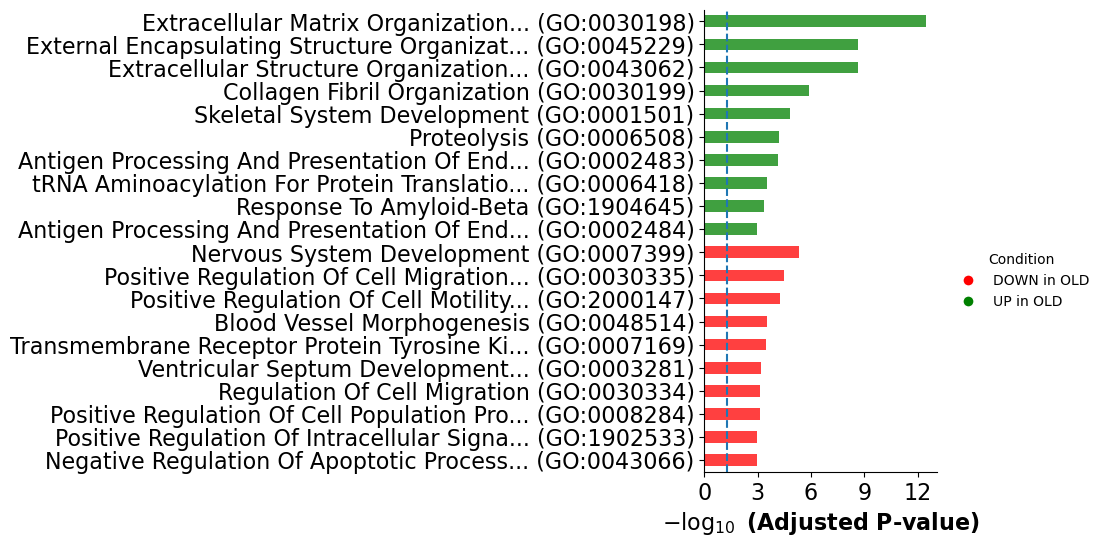

In [12]:
ax = barplot(
    young_old_go_results,
    column="Adjusted P-value",
    group="Condition",  # set group, so you could do a multi-sample/library comparsion
    size=10,
    top_term=10,
    figsize=(3, 6),
    color=["red", "green"]  # set colors for group
    # color={"UP_in_Old": "salmon", "MSigDB_Hallmark_2020": "darkblue"},
)
ax.axvline(x=-np.log10(0.05), linestyle="--")
plt.show()

## Transcription factor target enrichment analysis of DE protein coding genes

In [13]:
old_up_tft_results = perform_go_analysis(
    old_up_pc_genes,
    pc_universe,
    gene_sets="../data/genesets/tfs/c3.tft.v2023.2.Hs.symbols.gmt",
)

old_down_tft_results = perform_go_analysis(
    old_down_pc_genes,
    pc_universe,
    gene_sets="../data/genesets/tfs/c3.tft.v2023.2.Hs.symbols.gmt",
)
old_down_tft_results["Condition"] = "DOWN in OLD"
old_up_tft_results["Condition"] = "UP in OLD"

young_old_tft_results = pd.concat([old_down_tft_results, old_up_tft_results])

### Fig S13c

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/gseapy/plot.py:689: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(


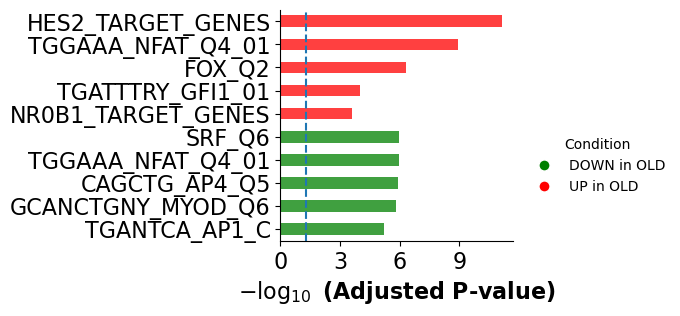

In [14]:
ax = barplot(
    young_old_tft_results.loc[~young_old_tft_results.Term.str.contains("UNKNOWN")],
    column="Adjusted P-value",
    group="Condition",  # set group, so you could do a multi-sample/library comparsion
    size=5,
    top_term=5,
    figsize=(3, 3),
    color={"red", "green"}  # set colors for group
    # color={"UP_in_Old": "salmon", "MSigDB_Hallmark_2020": "darkblue"},
)
ax.axvline(x=-np.log10(0.05), linestyle="--")

In [15]:
from collections import defaultdict

all_hgnc_symbols = list(
    pd.read_csv(
        "http://humantfs.ccbr.utoronto.ca/download/v_1.01/TF_names_v_1.01.txt"
    ).iloc[:, 0]
)
all_hgnc_symbols = [c.upper() for c in all_hgnc_symbols]
alpha = 0.05
young_old_tft_results.index = list(range(len(young_old_tft_results)))

tf_counts_up_in_old = defaultdict(int)
for idx in list(
    young_old_tft_results.loc[young_old_tft_results.Condition == "UP in OLD"].index
):
    entry = young_old_tft_results.loc[idx]
    if entry["Adjusted P-value"] < alpha:
        term = entry["Term"].split("_")
        for t in term:
            if t in all_hgnc_symbols:
                tf_counts_up_in_old[t] += 1
tf_counts_up_in_old = pd.DataFrame(
    pd.Series(tf_counts_up_in_old), columns=["n_sig_enriched"]
)

tf_counts_down_in_old = defaultdict(int)
for idx in list(
    young_old_tft_results.loc[young_old_tft_results.Condition == "DOWN in OLD"].index
):
    entry = young_old_tft_results.loc[idx]
    if entry["Adjusted P-value"] < alpha:
        term = entry["Term"].split("_")
        for t in term:
            if t.upper() in all_hgnc_symbols:
                tf_counts_down_in_old[t] += 1
tf_counts_down_in_old = pd.DataFrame(
    pd.Series(tf_counts_down_in_old), columns=["n_sig_enriched"]
)

## Fig S13d

<Axes: >

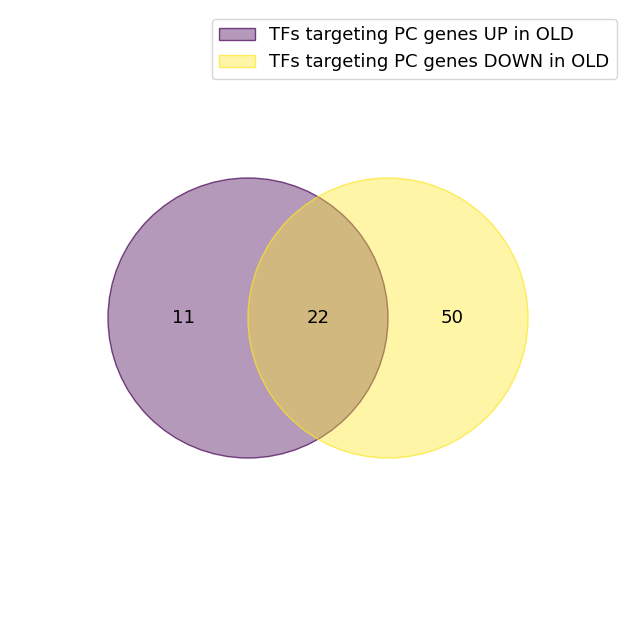

In [16]:
from venn import venn
venn(
    {
        "TFs targeting PC genes UP in OLD": set(list(tf_counts_up_in_old.index)),
        "TFs targeting PC genes DOWN in OLD": set(list(tf_counts_down_in_old.index)),
    }
)

## Aging geneset enrichment analysis

In [17]:
from utils.load_genesets import load_aging_genesets

In [22]:
aging_genesets = load_aging_genesets()
all_aging_genes = []
for genes in aging_genesets.values():
    all_aging_genes.extend(genes)

aging_genesets["ALL_SETS"] = list(set(all_aging_genes))

In [20]:
geneset_short_name_dict = {
    "SAUL_SEN_MAYO": "SenMayo",
    "REACTOME_TNF_SIGNALING": "TNF signaling (R)",
    "REACTOME_CELLULAR_SENESCENCE": "Senescence (R)",
    "REACTOME_SENESCENCE_ASSOCIATED_SECRETORY_PHENOTYPE_SASP": "SASP (R)",
    "KEGG_TGF_BETA_SIGNALING_PATHWAY": r"TGF$\beta$ signaling (K)",
    "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION": "EMT (H)",
    "HALLMARK_TGF_BETA_SIGNALING": r"TGF$\beta$ signaling (H)",
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB": r"TNF$\alpha$ signaling via Nf$\kappa$b (H)",
    "REACTOME_TGF_BETA": r"TGF$\beta$ signaling (R)",
    "ADHESOME": "Adhesome complex",
    "ALL_SETS": "All sets",
}

In [24]:
old_up_aging_results = perform_go_analysis(
    old_up_pc_genes,
    pc_universe,
    gene_sets=aging_genesets,
)

old_down_aging_results = perform_go_analysis(
    old_down_pc_genes, pc_universe, gene_sets=aging_genesets
)
old_down_aging_results["Condition"] = "DOWN in OLD"
old_up_aging_results["Condition"] = "UP in OLD"

young_old_aging_results = pd.concat([old_down_aging_results, old_up_aging_results])
young_old_aging_results.Term = young_old_aging_results.Term.map(geneset_short_name_dict)

### Fig S13e

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/gseapy/plot.py:689: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df[self.colname].replace(


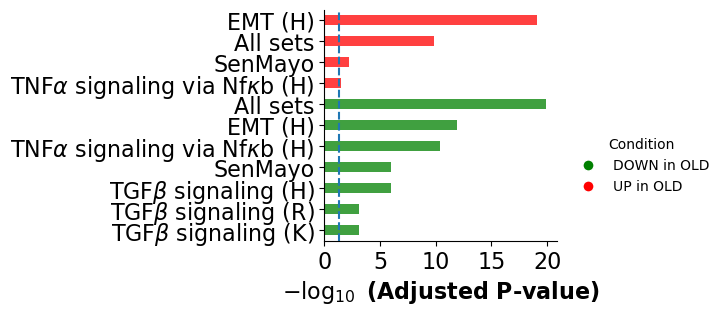

In [25]:
ax = barplot(
    young_old_aging_results,
    column="Adjusted P-value",
    group="Condition",  # set group, so you could do a multi-sample/library comparsion
    size=5,
    top_term=15,
    figsize=(3, 3),
    color={"red", "green"}  # set colors for group
    # color={"UP_in_Old": "salmon", "MSigDB_Hallmark_2020": "darkblue"},
)
ax.axvline(x=-np.log10(0.05), linestyle="--")
# ax.set_title("GO for cutoff of 5e-2")

# Enrichment analysis of the binding targets of the DE ncRNAs

## Generate binding target data

In [37]:
biomart_data = pd.read_csv("../data/genome_data/biomart_data.csv", index_col=0)
biomart_data.index = np.array(biomart_data.ensembl_gene_id)

hgnc_to_ensembl_dict = dict(
    zip(list(biomart_data.hgnc_symbol), list(biomart_data.ensembl_gene_id))
)

In [27]:
ens2hgnc_dict = {}
tmp = biomart_data[~biomart_data.index.duplicated(keep="first")]
for row in tqdm(tmp.iterrows()):
    ensid = row[1]["ensembl_gene_id"]
    symb = row[1]["hgnc_symbol"]
    symb = str(symb)
    if len(symb) > 10:
        symb = symb[:10] + "..."
    if symb == "nan":
        symb = "E" + ensid[-6:]
    ens2hgnc_dict[ensid] = symb

0it [00:00, ?it/s]

In [28]:
pc_genes = biomart_data.loc[
    biomart_data.gene_biotype == "protein_coding", "ensembl_gene_id"
].unique()

In [41]:
output_file = os.path.join("../data/young_old/binding_target_data.h5")
binding_target_data = pd.read_hdf(output_file, index_col=0)

gs_data = pd.read_csv("../data/genome_data/hg19/hg19_genecode_v19_release_13.sorted.bed",
    sep="\t",
    header=None,
)
gs_data = gs_data.iloc[:, :4]
gs_data.iloc[:, 3] = np.array([s.split(".")[0] for s in gs_data.iloc[:, 3]])
gs_data.iloc[:, 0] = np.array([s[3:] for s in gs_data.iloc[:, 0]])
gs_data.columns = [
    "ts_chromosome",
    "tss",
    "tes",
    "ensembl_id",
]
gs_data.index = np.array(gs_data.ensembl_id)

def get_loci_information(
    data, resolution=250e3, start_col="tss", end_col="tes", chrom_col="ia_chromosome"
):
    all_loci = []
    for i in tqdm(range(len(data))):
        entry = data.iloc[i]
        chrom = entry[chrom_col]
        start = entry[start_col]
        end = entry[end_col]
        start_locus = int(int(start / resolution) * resolution)
        end_locus = int(int(end / resolution) * resolution)
        loci = list(range(start_locus, end_locus + 1, int(resolution)))
        txt_loci = []
        for locus in loci:
            locus = "chr" + str(chrom) + "_loc_" + str(locus)
            txt_loci.append(locus)
        all_loci.append(txt_loci)
    return all_loci

gs_data["loci"] = get_loci_information(
    gs_data, resolution=250e3, start_col="tss", end_col="tes", chrom_col="ts_chromosome"
)

gs_data_exploded = (
    gs_data.copy()
    .set_index(list(set(gs_data.columns) - {"loci"}))
    .apply(pd.Series.explode)
    .reset_index()
)

  0%|          | 0/57820 [00:00<?, ?it/s]

In [42]:
controlled_bt_data = binding_target_data.loc[
    (binding_target_data.ncID_ensembl.isin(de_ncrnas))
    & (binding_target_data.close_gene.isin(pc_genes))
]
controlled_gene_data = gs_data_exploded.loc[
    (gs_data_exploded.ensembl_id.isin(pc_genes))
]

In [53]:
def run_enrichment_test_for_mutiple_genesets(
    binding_target_data,
    gene_data,
    geneset_dict,
    hgnc_to_ensembl_dict=None,
    n_perms=100,
    random_state=1234,
):
    all_enrichment_analyses_results_loci_gs = []
    for gs in geneset_dict.keys():
        gs_ens = geneset_dict[gs]
        if hgnc_to_ensembl_dict is not None:
            gs_ens = [
                hgnc_to_ensembl_dict[symb]
                for symb in gs_ens
                if symb in hgnc_to_ensembl_dict
            ]
        gs_loci = get_lociset_for_geneset(geneset=gs_ens, gs_data=gene_data)

        enrichment_analyses_results_loci_gs = run_enrichment_permutation_test_loci(
            binding_target_data=binding_target_data,
            gene_data=gene_data.loc[~gene_data.loci.isin(gs_loci)],
            lociset=list(gs_loci),
            n_perms=n_perms,
            random_state=random_state,
        )

        enrichment_analyses_results_loci_gs = pd.merge(
            enrichment_analyses_results_loci_gs,
            summarize_enrichment_results_loci(enrichment_analyses_results_loci_gs),
            left_on="ncID_ensembl",
            right_on="ncID_ensembl",
        )
        enrichment_analyses_results_loci_gs["geneset"] = gs
        all_enrichment_analyses_results_loci_gs.append(
            enrichment_analyses_results_loci_gs
        )
    all_enrichment_analyses_results_loci_gs = pd.concat(
        all_enrichment_analyses_results_loci_gs
    )
    return all_enrichment_analyses_results_loci_gs

def get_lociset_for_geneset(geneset, gs_data, id_col="ensembl_id", loci_col="loci"):
    lociset = set(
        list(gs_data.loc[gs_data.loc[:, id_col].isin(geneset), loci_col].unique())
    )
    return lociset

def run_enrichment_permutation_test_loci(
    binding_target_data, gene_data, lociset, n_perms=1000, random_state=1234
):
    np.random.seed(random_state)
    all_enrichment_scores = []
    for b in tqdm(range(n_perms), position=0):
        perm_lociset = get_controlled_random_lociset(gene_data, lociset)
        enrichment_scores = compute_enrichment_scores_loci(
            binding_target_data, perm_lociset
        )
        all_enrichment_scores.append(enrichment_scores)
    all_enrichment_scores = pd.concat(all_enrichment_scores)
    all_enrichment_scores["observation_type"] = "permuted"

    enrichment_scores = compute_enrichment_scores_loci(binding_target_data, lociset)
    enrichment_scores["observation_type"] = "observed"
    all_enrichment_scores = pd.concat([all_enrichment_scores, enrichment_scores])
    return all_enrichment_scores

def compute_enrichment_scores_loci(bs_data, lociset):
    result = {
        "ncID_ensembl": [],
        "n_loci_of_lociset_bound": [],
        "n_total_loci_bound": [],
        "n_total_loci_in_lociset": [],
    }
    for ncrna in bs_data.ncID_ensembl.unique():
        entry = bs_data.loc[bs_data.ncID_ensembl == ncrna]
        n_total_loci_bound = entry.locus.nunique()

        n_total_bs = entry.bs_idx.nunique()

        lociset_entry = entry.loc[entry.locus.isin(lociset)]
        n_bs_in_lociset = lociset_entry.bs_idx.nunique()

        n_loci_of_lociset_bound = lociset_entry.locus.nunique()

        result["ncID_ensembl"].append(ncrna)
        result["n_loci_of_lociset_bound"].append(n_loci_of_lociset_bound)
        result["n_total_loci_bound"].append(n_total_loci_bound)
        result["n_total_loci_in_lociset"].append(len(lociset))
    return pd.DataFrame(result)

from collections import Counter

def get_controlled_random_lociset(
    gs_data,
    lociset,
    id_col="ensembl_id",
    loci_col="loci",
    chrom_col="ts_chromosome",
    random_state=None,
):
    np.random.seed(random_state)
    sampled_loci = []
    loci_chroms = []
    for locus in lociset:
        loci_chroms.append(locus.split("_")[0][3:])
    loci_chrom_counts = dict(Counter(loci_chroms))
    for chrom, count in loci_chrom_counts.items():
        entry = gs_data.loc[gs_data.loc[:, chrom_col] == chrom]
        sampled_loci.extend(
            np.random.choice(list(entry[loci_col].unique()), size=count, replace=False)
        )
    return set(sampled_loci)

from statsmodels.stats.multitest import fdrcorrection

def summarize_enrichment_results_loci(data):
    results = {
        "ncID_ensembl": [],
        "n_loci_pval": [],
        # "n_bs_pval": []
    }
    for ncrna in tqdm(data.ncID_ensembl.unique()):
        results["ncID_ensembl"].append(ncrna)
        entry = data.loc[data.ncID_ensembl == ncrna]
        entry_observed = entry.loc[entry.observation_type == "observed"]
        assert len(np.array(entry_observed.n_loci_of_lociset_bound)) == 1
        # assert len(np.array(entry_observed.n_bs_in_lociset)) == 1
        entry_perm = entry.loc[entry.observation_type == "permuted"]

        n_loci_pval = np.mean(
            np.array(entry_perm.n_loci_of_lociset_bound)
            >= np.array(entry_observed.n_loci_of_lociset_bound)[0]
        )
        results["n_loci_pval"].append(n_loci_pval)

    results = pd.DataFrame(results)

    results.loc[:, "n_loci_pval_fdr"] = fdrcorrection(
        np.array(results.loc[:, "n_loci_pval"])
    )[1]
    return results

In [54]:
all_de_ncrna_enrichment_results = run_enrichment_test_for_mutiple_genesets(
     binding_target_data=controlled_bt_data,
     gene_data=controlled_gene_data,
     geneset_dict=aging_genesets,
     hgnc_to_ensembl_dict=hgnc_to_ensembl_dict,
     n_perms=100,
     random_state=1234,
)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/102 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/102 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/102 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/102 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/102 [00:00<?, ?it/s]

In [57]:
sig_enr_analyses_results = all_de_ncrna_enrichment_results.loc[
    (all_de_ncrna_enrichment_results.n_loci_pval_fdr < 0.05)
    & (all_de_ncrna_enrichment_results.observation_type == "observed"),
].sort_values("ncID_ensembl")

sig_enr_analyses_results["DE"] = "UP in OLD"

sig_enr_analyses_results.loc[
    sig_enr_analyses_results.ncID_ensembl.isin(ncrnas_down_in_old),
    "DE"
] = "DOWN in OLD"

In [60]:
# sig_enr_analyses_results.to_csv("../data/young_old/sig_enr_results_youngold.csv")

In [67]:
sig_enr_analyses_results = pd.read_csv("../data/young_old/sig_enr_results_youngold.csv",
    index_col=0,
)

sig_enr_analyses_results["hgnc_symb"] = sig_enr_analyses_results.ncID_ensembl.map(
    ens2hgnc_dict
)

In [71]:
vis_enr_mtx = np.zeros(
    [sig_enr_analyses_results.ncID_ensembl.nunique(), len(aging_genesets)]
)
vis_enr_mtx = pd.DataFrame(
    vis_enr_mtx,
    index=sig_enr_analyses_results.ncID_ensembl.unique(),
    columns=list(aging_genesets.keys()),
)

for ncrna in vis_enr_mtx.index:
    for gs in vis_enr_mtx.columns:
        if (
            len(
                sig_enr_analyses_results.loc[
                    (sig_enr_analyses_results.ncID_ensembl == ncrna)
                    & (sig_enr_analyses_results.geneset == gs)
                ]
            )
            > 0
        ):
            vis_enr_mtx.loc[ncrna, gs] = 1
vis_enr_mtx.index = vis_enr_mtx.index.map(ens2hgnc_dict)
vis_enr_mtx.columns = vis_enr_mtx.columns.map(geneset_short_name_dict)

## Fig 3b

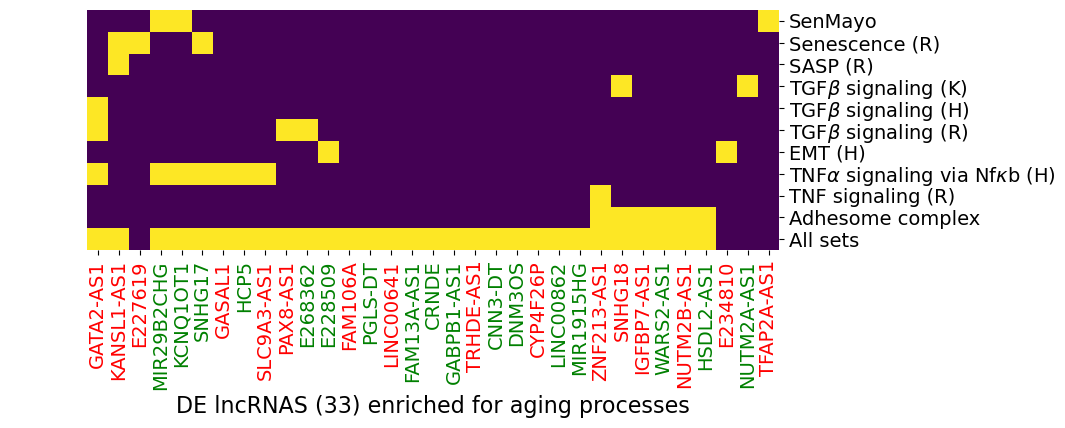

In [72]:
g = sns.clustermap(
    vis_enr_mtx.transpose(),
    col_cluster=True,
    row_cluster=False,
    dendrogram_ratio=0.1,
    cbar_pos=(0, 0, 0, 0),
    figsize=[10, 4],
    cmap="viridis",
    linewidths=0,
    xticklabels=True,
)
colors = {
    "DOWN in OLD": "red",
    "UP in OLD": "green",
}
g.ax_col_dendrogram.set_visible(False)
for tick_label in g.ax_heatmap.axes.get_xticklabels():
    tick_text = tick_label.get_text()
    de_color = sig_enr_analyses_results.loc[
        sig_enr_analyses_results.hgnc_symb == tick_text, "DE"
    ].values[0]
    tick_label.set_color(colors[de_color])

g.ax_heatmap.set_xlabel("DE lncRNAS (33) enriched for aging processes")

# Set tick font size
g.ax_heatmap.tick_params(axis="x", labelsize=14)
g.ax_heatmap.tick_params(axis="y", labelsize=14)

# Set axis label font size
g.ax_heatmap.set_xlabel("DE lncRNAS (33) enriched for aging processes", fontsize=16)
g.ax_heatmap.set_ylabel(g.ax_heatmap.get_ylabel(), fontsize=16)

g.cax.remove()
